# Part 1 - Setup & Exploratory Data Analysis (EDA)

### 1.import neccesary libraries

In [93]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')

### 2. Problem Definition.

The objective of this project is to build and compare three machine learning models
for classifying breast tumors as either malignant or benign.

The models to be compared are:

- Decision Tree
- Random Forest
- Gradient Boosting

The workflow follows an end-to-end machine learning pipeline including:

1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Model Training
4. Model Evaluation
5. Model Comparison
6. Error Analysis
7. Conclusion

### 3. Load dataset

In [94]:
# Load dataset
breast = load_breast_cancer(as_frame=True)

# Convert to DataFrame
df = breast.frame.copy()

# Display first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 4. Dataset information

In [95]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (569, 31)


In [96]:
print(df.columns.tolist())

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

### 5. Dataset validation

In [98]:
# Check Missing Values
missing = df.isnull().sum()
missing

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [99]:
# check duplicate rows 
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [100]:
# check target classes
# 0 = malignant
# 1 = benign
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

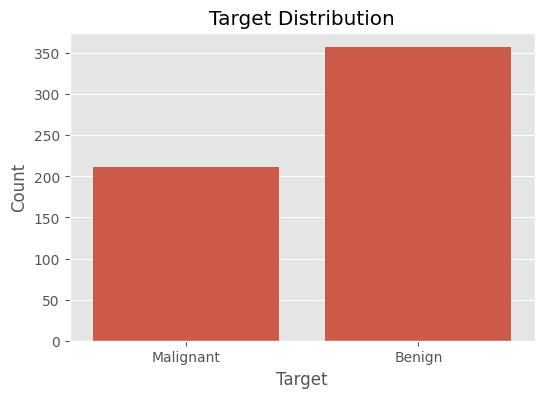

In [101]:
# The dataset is slightly imbalanced,
# with more benign samples than malignant samples.
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='target')

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.xticks(
    ticks=[0,1],
    labels=["Malignant","Benign"]
)

plt.show()

In [102]:
class_percentage = (
    df['target']
    .value_counts(normalize=True)
    *100
)

print(class_percentage)

target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


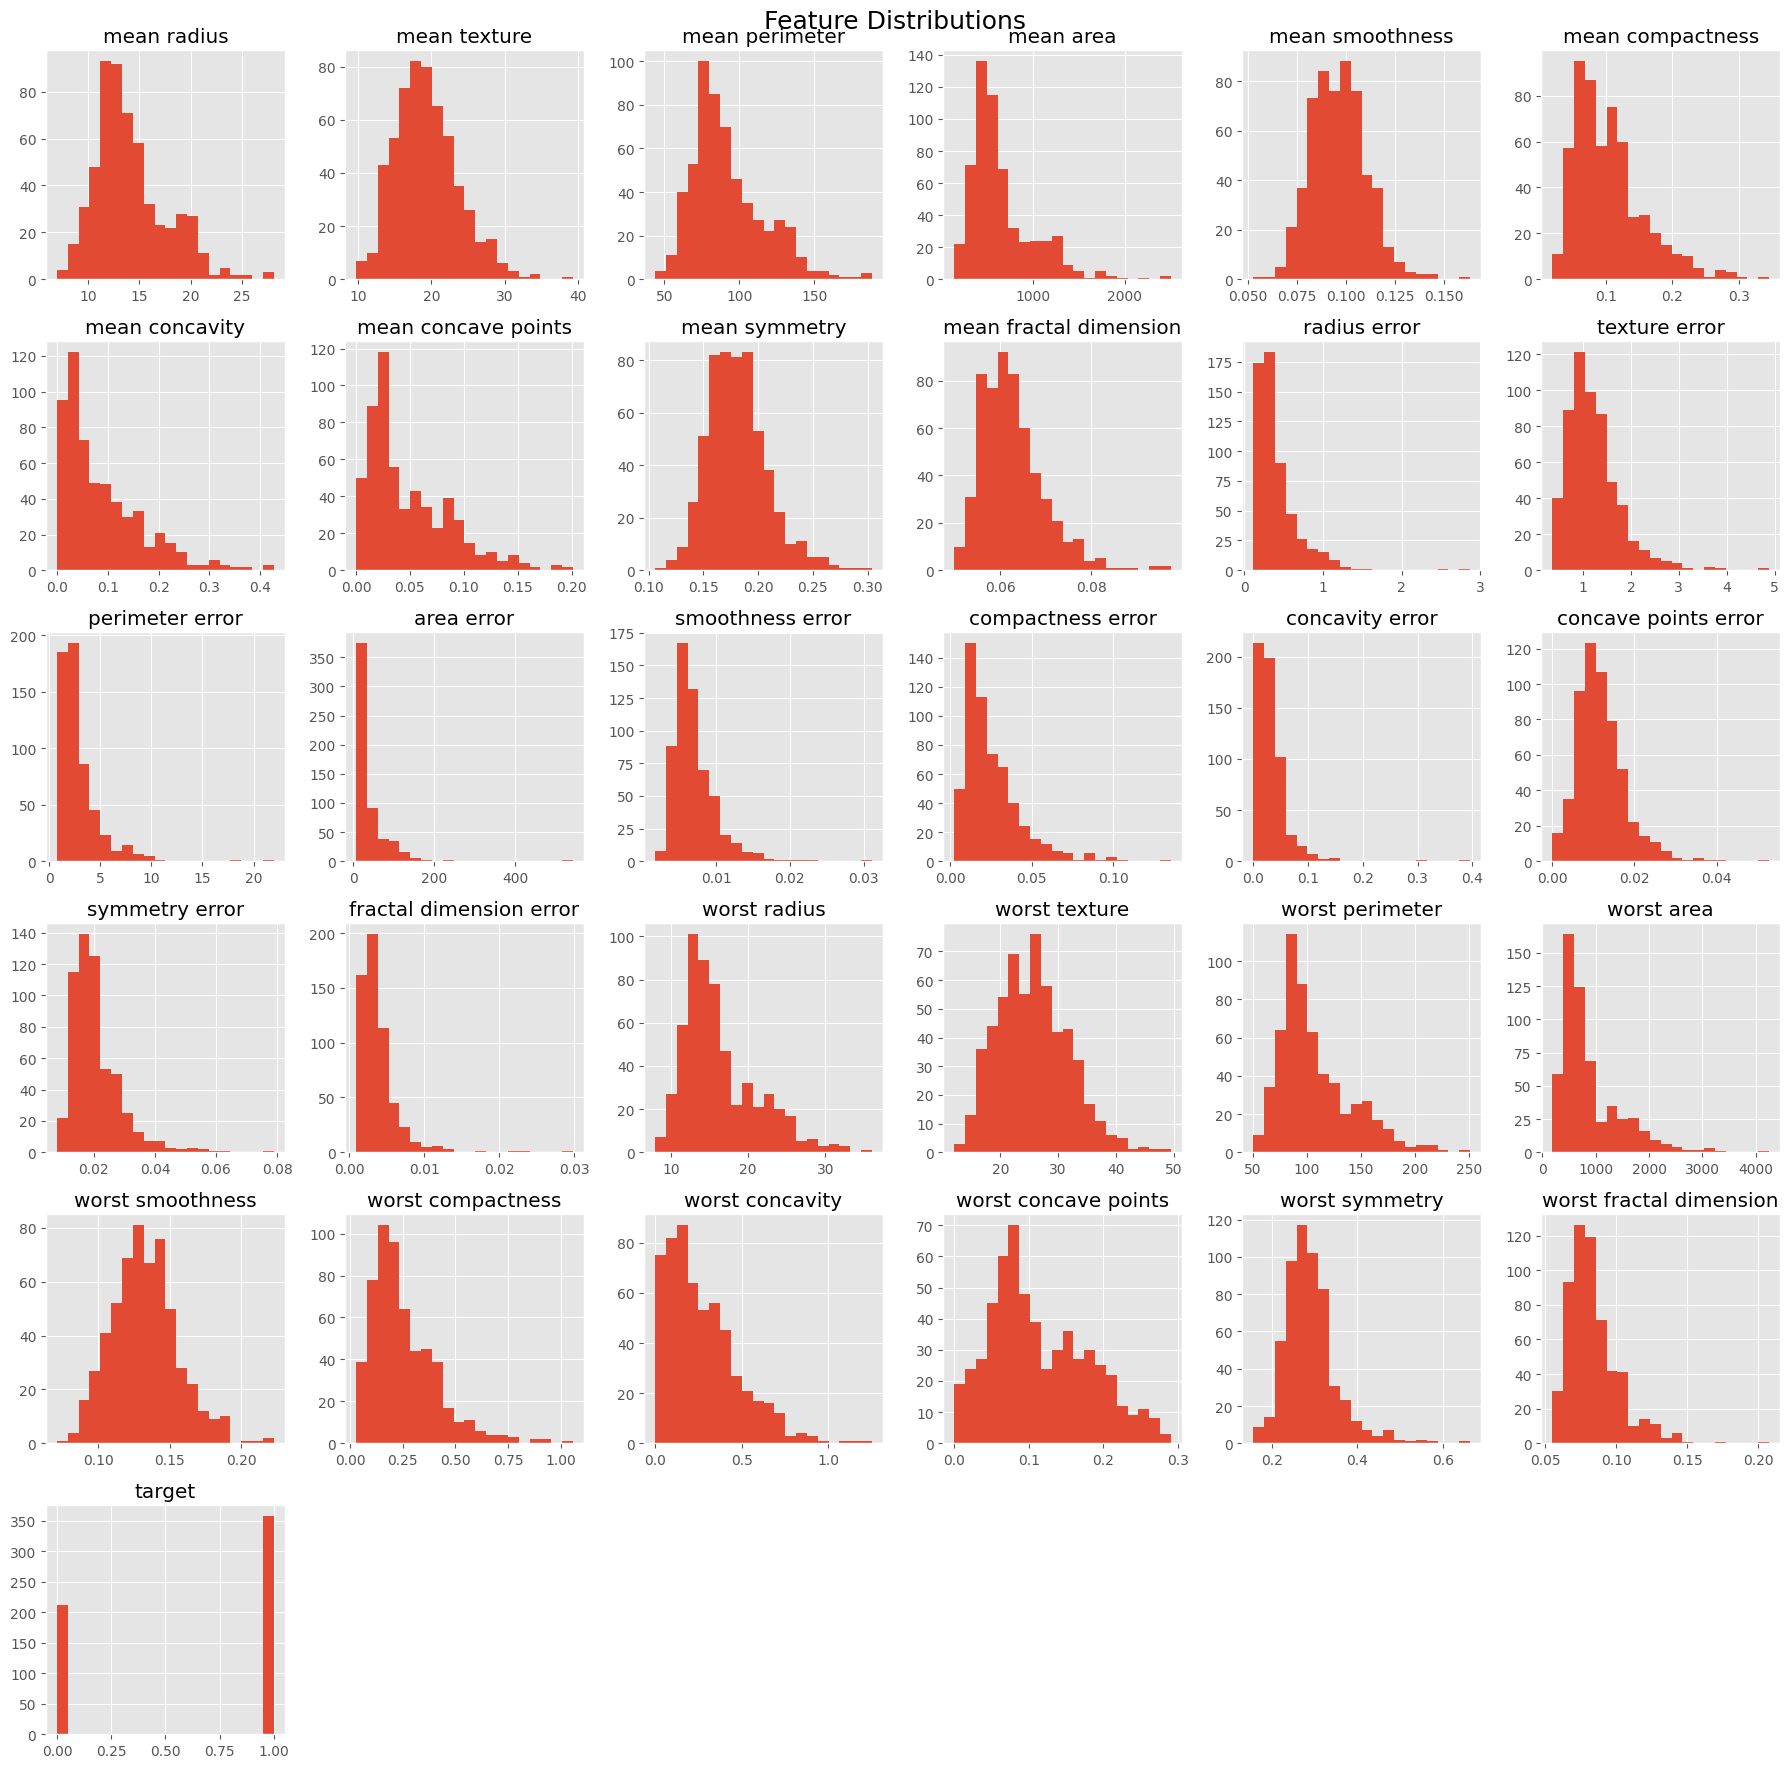

In [103]:
df.hist(
    figsize=(18,18),
    bins=20
)

plt.suptitle("Feature Distributions", fontsize=18)

plt.tight_layout()

plt.show()

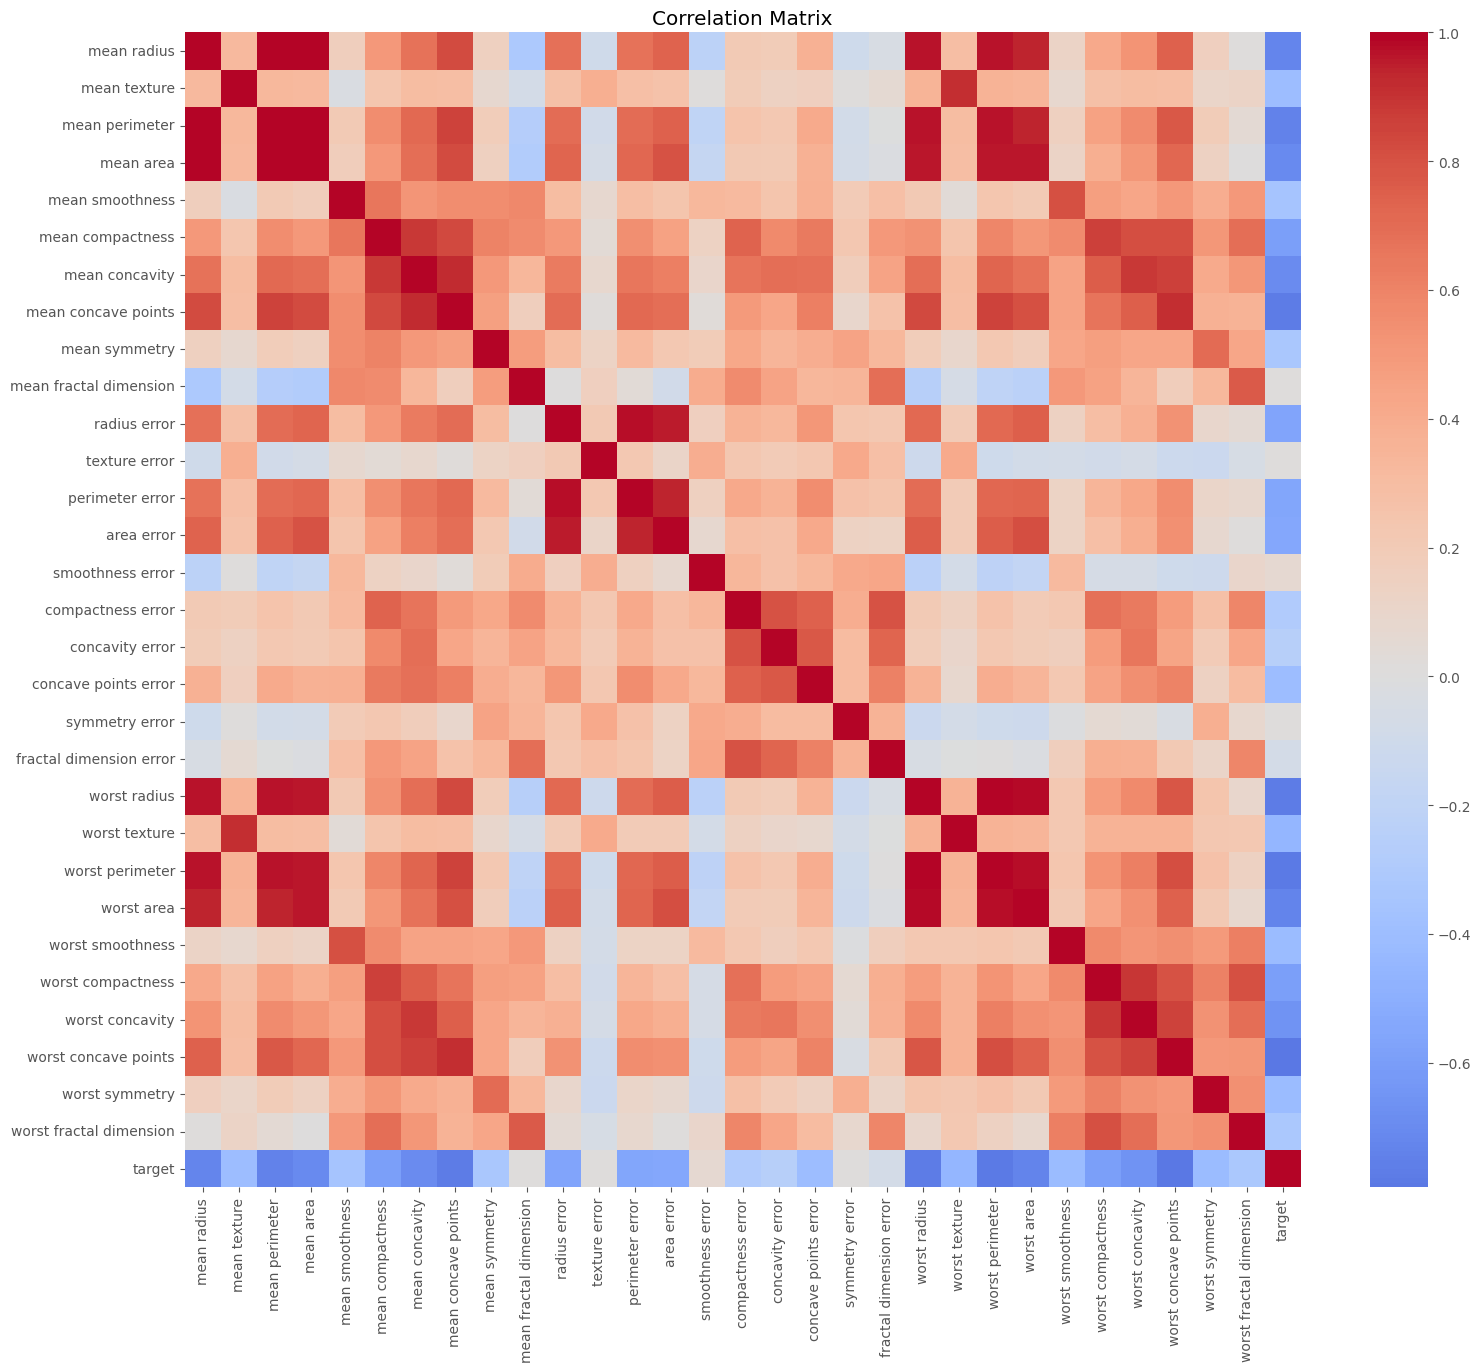

In [104]:
# Correlation matrix
corr = df.corr()

plt.figure(figsize=(18,15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [105]:
# Top correlated feature with Target
target_corr = (
    corr['target']
    .sort_values(ascending=False)
)

target_corr

target                     1.000000
smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0

## EDA Summary

### Findings

- The dataset contains **569 observations** and **30 numerical features**.
- There are **no missing values**.
- There are **no duplicate records**.
- All features are numerical.
- The target variable consists of two classes:
  - Malignant
  - Benign
- The dataset is slightly imbalanced but remains suitable for classification.
- Several features show strong correlations, particularly measurements related to tumor size such as radius, perimeter, and area.
- Some features contain outliers, which is expected in medical datasets.
- Since all selected models are tree-based, feature scaling is not required.

### Next Step

Proceed to data preprocessing and train-test splitting before training the machine learning models.

# Part 2 – Data Preprocessing

### 1. Separate Features and Target

In [106]:
# Features (X) and target (y)
X = df.drop(columns='target')
y = df['target']

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Features Shape: (569, 30)
Target Shape: (569,)


### 2. Check Feature and Target

In [107]:
print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Target:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### 3. Split Training, Validation and Testing Data

In [108]:
from sklearn.model_selection import train_test_split

# First split: 80% train+validation, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [109]:
# Second split: 75% train, 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

In [110]:
print("Training Set :", X_train.shape)
print("Validation Set:", X_val.shape)
print("Testing Set :", X_test.shape)

Training Set : (341, 30)
Validation Set: (114, 30)
Testing Set : (114, 30)


In [111]:
print("Training Set")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation Set")
print(y_val.value_counts(normalize=True) * 100)

print("\nTesting Set")
print(y_test.value_counts(normalize=True) * 100)

Training Set
target
1    62.756598
0    37.243402
Name: proportion, dtype: float64

Validation Set
target
1    62.280702
0    37.719298
Name: proportion, dtype: float64

Testing Set
target
1    63.157895
0    36.842105
Name: proportion, dtype: float64


### 6. Visualize class distribution

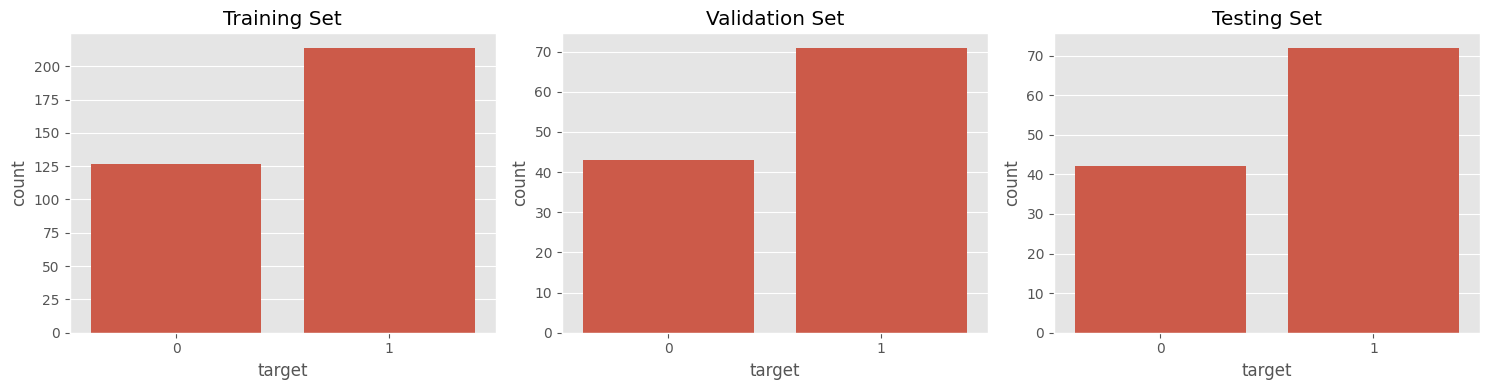

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Training Set")

sns.countplot(x=y_val, ax=axes[1])
axes[1].set_title("Validation Set")

sns.countplot(x=y_test, ax=axes[2])
axes[2].set_title("Testing Set")

plt.tight_layout()
plt.show()

# Part 3 – Decision Tree Classifier

### 1.Import Required Libraries

In [113]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

### 2. Build the Decision Tree Model

In [114]:
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

### 3. Train the Model

In [115]:
decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### 4. Make Predictions on Validation Set

In [116]:
y_val_pred_dt = decision_tree.predict(X_val)

### 5. Evaluate Model Performance

In [117]:
dt_accuracy = accuracy_score(y_val, y_val_pred_dt)
dt_precision = precision_score(y_val, y_val_pred_dt)
dt_recall = recall_score(y_val, y_val_pred_dt)
dt_f1 = f1_score(y_val, y_val_pred_dt)

### 6. Display Evaluation Metrics

In [118]:
print("Decision Tree Performance (Validation Set)")
print("-" * 45)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-score : {dt_f1:.4f}")

Decision Tree Performance (Validation Set)
---------------------------------------------
Accuracy : 0.9561
Precision: 0.9853
Recall   : 0.9437
F1-score : 0.9640


### 7. Confusion Matrix

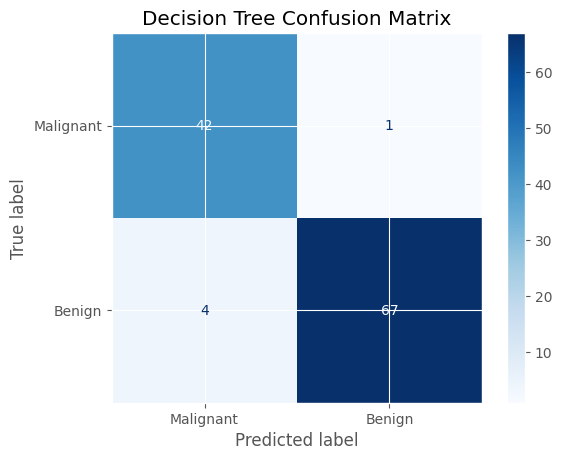

In [119]:
cm = confusion_matrix(y_val, y_val_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")

plt.show()

### 8. Classification report

In [120]:

print(
    classification_report(
        y_val,
        y_val_pred_dt,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        43
      Benign       0.99      0.94      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## Strengths

- Easy to understand and interpret.
- Provides clear decision rules.
- Handles nonlinear relationships naturally.
- Requires little data preprocessing.
- Can estimate feature importance.
## Weaknesses

- Prone to overfitting if the tree grows too deep.
- Small changes in the data can produce a very different tree.
- Generally less accurate than ensemble methods such as Random Forest or Gradient Boosting.

### Part 4 – Random Forest Classifier

### 1. Import Required Libraries

In [121]:
from sklearn.ensemble import RandomForestClassifier

### 2. Build the Random Forest Model

In [122]:

random_forest = RandomForestClassifier(
    random_state=42
)

### 3. Train the Model

In [123]:
random_forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 4. Predict on the Validation Set

In [124]:
y_val_pred_rf = random_forest.predict(X_val)

### 5. Evaluate the Model

In [125]:

rf_accuracy = accuracy_score(y_val, y_val_pred_rf)

rf_precision = precision_score(y_val, y_val_pred_rf)

rf_recall = recall_score(y_val, y_val_pred_rf)

rf_f1 = f1_score(y_val, y_val_pred_rf)

In [126]:
print("Random Forest Performance (Validation Set)")
print("-" * 45)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

Random Forest Performance (Validation Set)
---------------------------------------------
Accuracy : 0.9561
Precision: 0.9583
Recall   : 0.9718
F1-score : 0.9650


### 6. Confusion Matrix

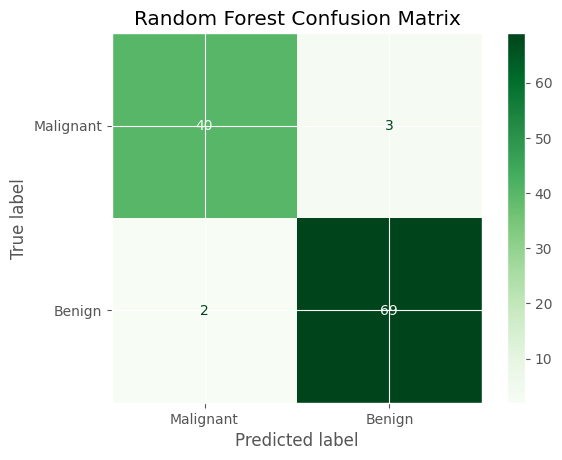

In [127]:
cm = confusion_matrix(
    y_val,
    y_val_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Greens")

plt.title("Random Forest Confusion Matrix")

plt.show()

### 7. Classification Report

In [128]:
print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        43
      Benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## Strengths

- Higher accuracy than a single Decision Tree.
- Reduces overfitting through ensemble learning.
- More robust to noisy data.
- Handles nonlinear relationships effectively.
- Provides reliable feature importance estimates.
## Weaknesses

- Less interpretable than a single Decision Tree.
- Requires more memory and computation.
- Training time increases as the number of trees grows.

# Part 5 – Gradient Boosting Classifier

### 1. Import Required Libraries

In [129]:
from sklearn.ensemble import GradientBoostingClassifier

### 2. Build the Gradient Boosting Model

In [130]:
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

### 3. Train the Model

In [131]:
gradient_boosting.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

### 4. Predict on the Validation Set

In [132]:
y_val_pred_gb = gradient_boosting.predict(X_val)

### 5. Evaluate the Model

In [133]:
gb_accuracy = accuracy_score(
    y_val,
    y_val_pred_gb
)

gb_precision = precision_score(
    y_val,
    y_val_pred_gb
)

gb_recall = recall_score(
    y_val,
    y_val_pred_gb
)

gb_f1 = f1_score(
    y_val,
    y_val_pred_gb
)

In [134]:
print("Gradient Boosting Performance (Validation Set)")
print("-" * 50)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1-score : {gb_f1:.4f}")

Gradient Boosting Performance (Validation Set)
--------------------------------------------------
Accuracy : 0.9649
Precision: 0.9718
Recall   : 0.9718
F1-score : 0.9718


### 6. Confusion Matrix

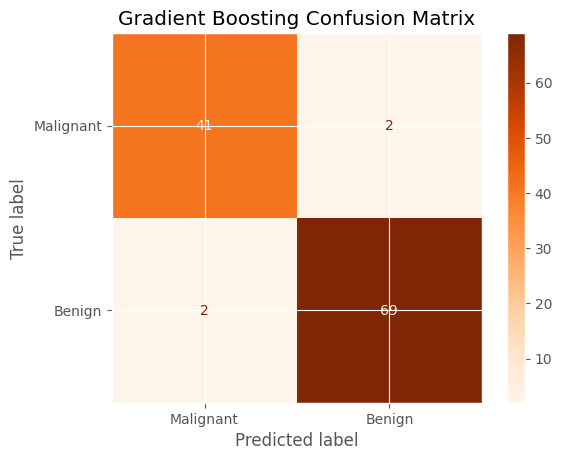

In [135]:
cm = confusion_matrix(
    y_val,
    y_val_pred_gb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Malignant", "Benign"]
)

disp.plot(cmap="Oranges")

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

### 7. Classification Report

In [136]:
print(
    classification_report(
        y_val,
        y_val_pred_gb,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        43
      Benign       0.97      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



## Strengths

- Often achieves the highest predictive performance.
- Learns complex nonlinear relationships.
- Reduces bias by sequentially correcting previous mistakes.
- Handles difficult classification tasks effectively.
- Produces reliable feature importance estimates.
## Weaknesses

- Training is slower than Decision Tree and Random Forest.
- More sensitive to hyperparameter settings.
- Can overfit if the number of boosting stages is too large.
- Less interpretable than a single Decision Tree.

# Part 6 – Model Comparison & Best Model Selection


### 1. Create Comparison Table

In [137]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall,
        gb_recall
    ],
    "F1-score": [
        dt_f1,
        rf_f1,
        gb_f1
    ]
})

# round the results
comparison_df.iloc[:,1:] = comparison_df.iloc[:,1:].round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.9561,0.9853,0.9437,0.9640
1,Random Forest,0.9561,0.9583,0.9718,0.9650
2,Gradient Boosting,0.9649,0.9718,0.9718,0.9718


### 2. Overall Metric Comparison

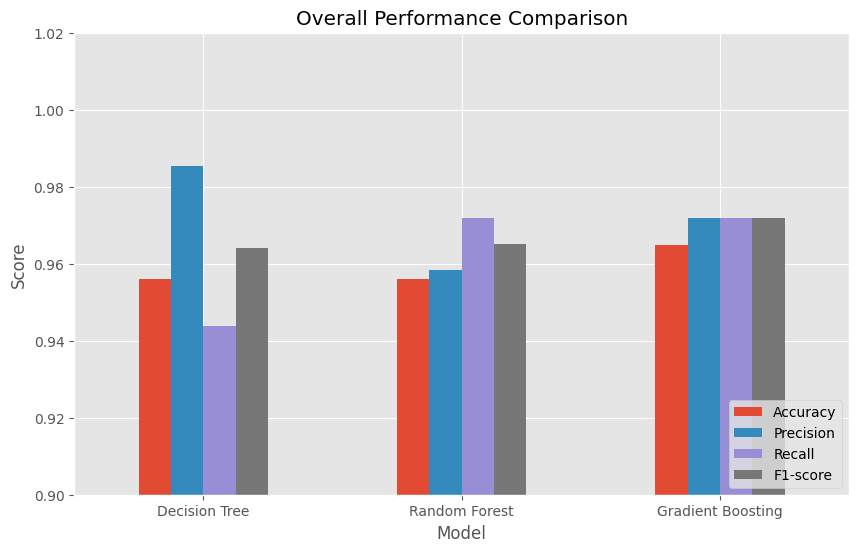

In [138]:
comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Overall Performance Comparison")

plt.ylabel("Score")

plt.ylim(0.9,1.02)

plt.xticks(rotation=0)

plt.legend(loc="lower right")

plt.show()

## Model Comparison

### Decision Tree

- Fast training
- Highly interpretable
- Prone to overfitting

### Random Forest

- Better generalization
- Higher accuracy
- More robust to noisy data

### Gradient Boosting

- Highest predictive performance
- Learns from previous mistakes
- Computationally more expensive

In [139]:

best_model_name = comparison_df.loc[
    comparison_df["F1-score"].idxmax(),
    "Model"
]

print(f"Best Model: {best_model_name}")

Best Model: Gradient Boosting


## Best Model

Gradient Boosting achieved the highest F1-score among the three models.

Compared with Decision Tree and Random Forest, it produced fewer classification errors and demonstrated stronger generalization on the validation dataset.

Therefore, Gradient Boosting is selected as the final model for evaluation on the unseen test dataset.

In [140]:
models = {
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}

best_model = models[best_model_name]

## Model Comparison Summary

Three machine learning models were trained and evaluated using the validation dataset.

The evaluation metrics included:

- Accuracy
- Precision
- Recall
- F1-score

The results were summarized in a comparison table and visualized using bar charts.

Based on the F1-score, the best-performing model was selected for final evaluation on the unseen test dataset.

# Part 7 – Final Evaluation & Error Analysis

### 1. Evaluate the Best Model on the Test Set

In [141]:
# Predict on the test set
y_test_pred = best_model.predict(X_test)

### 2. Calculate Evaluation Metrics

In [142]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

In [143]:
print("Final Evaluation on Test Set")
print("-" * 40)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

Final Evaluation on Test Set
----------------------------------------
Accuracy : 0.9298
Precision: 0.9444
Recall   : 0.9444
F1-score : 0.9444


### 3. Confusion matrix

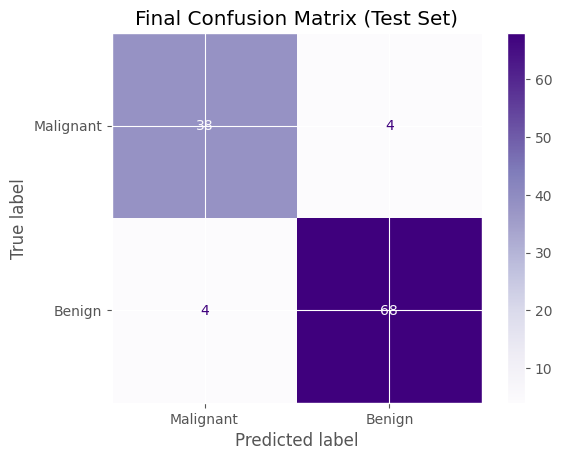

In [144]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Malignant",
        "Benign"
    ]
)

disp.plot(cmap="Purples")

plt.title("Final Confusion Matrix (Test Set)")

plt.show()

### 4. Classification Report

In [145]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Malignant",
            "Benign"
        ]
    )
)

              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



### 5.Create Error Analysis DataFrame

In [146]:
error_df = X_test.copy()

error_df["Actual"] = y_test.values

error_df["Predicted"] = y_test_pred

error_df["Correct"] = (
    error_df["Actual"]
    ==
    error_df["Predicted"]
)

### 6.Display Incorrect Predictions

In [147]:
wrong_predictions = error_df[
    error_df["Correct"] == False
]

print(f"Number of Misclassified Samples: {len(wrong_predictions)}")

wrong_predictions.head()

Number of Misclassified Samples: 8


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Correct
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,0.3389,1.4390,2.344,33.58,0.007257,0.01805,0.01832,0.010330,0.01694,0.002001,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.16630,0.09123,0.2394,0.06469,1,0,False
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,0.2366,1.4280,1.822,16.97,0.008064,0.01764,0.02595,0.010370,0.01357,0.003040,12.84,35.34,87.22,514.0,0.1909,0.26980,0.40230,0.14240,0.2964,0.09606,0,1,False
275,11.89,17.36,76.20,435.6,0.12250,0.07210,0.05929,0.07404,0.2015,0.05875,0.6412,2.2930,4.021,48.84,0.014180,0.01489,0.01267,0.019100,0.02678,0.003002,12.40,18.99,79.46,472.4,0.1359,0.08368,0.07153,0.08946,0.2220,0.06033,1,0,False
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,0.2787,0.6205,1.957,23.35,0.004717,0.02065,0.01759,0.009206,0.01220,0.003130,16.57,20.86,110.30,812.4,0.1411,0.35420,0.27790,0.13830,0.2589,0.10300,0,1,False
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,0.4157,1.6270,2.914,33.01,0.008312,0.01742,0.03389,0.015760,0.01740,0.002871,15.79,31.71,102.20,758.2,0.1312,0.15810,0.26750,0.13590,0.2477,0.06836,0,1,False


In [148]:
correct = error_df["Correct"].sum()

incorrect = len(error_df) - correct

print(f"Correct Predictions   : {correct}")

print(f"Incorrect Predictions : {incorrect}")

Correct Predictions   : 106
Incorrect Predictions : 8


### 7.False Positives and False Negatives

In [149]:
false_positive = error_df[
    (error_df["Actual"] == 0)
    &
    (error_df["Predicted"] == 1)
]

false_negative = error_df[
    (error_df["Actual"] == 1)
    &
    (error_df["Predicted"] == 0)
]

In [150]:
print("False Positives")

display(false_positive)

False Positives


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Correct
41,10.95,21.35,71.90,371.1,0.12270,0.12180,0.10440,0.05669,0.1895,0.06870,0.2366,1.4280,1.822,16.97,0.008064,0.01764,0.02595,0.010370,0.01357,0.003040,12.84,35.34,87.22,514.0,0.1909,0.2698,0.4023,0.1424,0.2964,0.09606,0,1,False
73,13.80,15.79,90.43,584.1,0.10070,0.12800,0.07789,0.05069,0.1662,0.06566,0.2787,0.6205,1.957,23.35,0.004717,0.02065,0.01759,0.009206,0.01220,0.003130,16.57,20.86,110.30,812.4,0.1411,0.3542,0.2779,0.1383,0.2589,0.10300,0,1,False
385,14.60,23.29,93.97,664.7,0.08682,0.06636,0.08390,0.05271,0.1627,0.05416,0.4157,1.6270,2.914,33.01,0.008312,0.01742,0.03389,0.015760,0.01740,0.002871,15.79,31.71,102.20,758.2,0.1312,0.1581,0.2675,0.1359,0.2477,0.06836,0,1,False
205,15.12,16.68,98.78,716.6,0.08876,0.09588,0.07550,0.04079,0.1594,0.05986,0.2711,0.3621,1.974,26.44,0.005472,0.01919,0.02039,0.008260,0.01523,0.002881,17.77,20.24,117.70,989.5,0.1491,0.3331,0.3327,0.1252,0.3415,0.09740,0,1,False


In [151]:
print("False Negatives")

display(false_negative)

False Negatives


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Actual,Predicted,Correct
363,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,0.3389,1.439,2.344,33.58,0.007257,0.01805,0.01832,0.01033,0.01694,0.002001,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.16630,0.09123,0.2394,0.06469,1,0,False
275,11.89,17.36,76.20,435.6,0.12250,0.07210,0.05929,0.07404,0.2015,0.05875,0.6412,2.293,4.021,48.84,0.014180,0.01489,0.01267,0.01910,0.02678,0.003002,12.40,18.99,79.46,472.4,0.1359,0.08368,0.07153,0.08946,0.2220,0.06033,1,0,False
291,14.96,19.10,97.03,687.3,0.08992,0.09823,0.05940,0.04819,0.1879,0.05852,0.2877,0.948,2.171,24.87,0.005332,0.02115,0.01536,0.01187,0.01522,0.002815,16.25,26.19,109.10,809.8,0.1313,0.30300,0.18040,0.14890,0.2962,0.08472,1,0,False
128,15.10,16.39,99.58,674.5,0.11500,0.18070,0.11380,0.08534,0.2001,0.06467,0.4309,1.068,2.796,39.84,0.009006,0.04185,0.03204,0.02258,0.02353,0.004984,16.11,18.33,105.90,762.6,0.1386,0.28830,0.19600,0.14230,0.2590,0.07779,1,0,False


In [152]:
print(f"False Positives : {len(false_positive)}")

print(f"False Negatives : {len(false_negative)}")

False Positives : 4
False Negatives : 4


## Error Analysis

The selected model achieved strong predictive performance on the unseen test dataset. However, a small number of samples were still misclassified.

### False Positives

False positives occur when malignant tumors are incorrectly classified as benign.

These errors may arise because some malignant tumors exhibit feature values that closely resemble benign tumors.

### False Negatives

False negatives occur when benign tumors are predicted as malignant.

Although these cases are less dangerous in terms of missed cancer diagnosis, they may lead to unnecessary follow-up examinations and treatments.

### Possible Reasons

- Overlapping feature distributions.
- Limited number of training samples.
- Noise in medical measurements.
- Default model hyperparameters.

## Final Evaluation Summary

The best-performing model selected from the validation stage was evaluated on the unseen test dataset.

The model achieved high Accuracy, Precision, Recall, and F1-score, indicating strong generalization performance.

Only a small number of samples were misclassified. Most errors occurred in cases where the feature values of malignant and benign tumors were highly similar.

Overall, the model demonstrated reliable classification performance on the Breast Cancer Wisconsin dataset.